# Genomic Benchmarks — Dataset Exploration

This notebook loads the `dummy_mouse_enhancers_ensembl` dataset and explores its statistics:
- Class distribution
- Sequence length distribution
- Nucleotide composition (A/C/G/T/N frequencies)
- GC content
- N-base contamination
- One-hot featurization shape check

In [1]:
import logging
logging.basicConfig(level=logging.INFO)

import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

from deepchem_genomics.molnet import load_genomic_benchmark
from deepchem_genomics.features import DNAOneHotFeaturizer, DNAKmerFeaturizer

/Users/aryamanbahl/miniconda3/envs/deepchem/lib/python3.8/site-packages/genomic_benchmarks/utils/datasets.py:11: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from tqdm.autonotebook import tqdm


## 1. Load the dataset

In [2]:
DATASET_NAME = "dummy_mouse_enhancers_ensembl"

tasks, datasets, transformers = load_genomic_benchmark(DATASET_NAME)
train, valid, test = datasets

print(f"Dataset: {DATASET_NAME}")
print(f"Tasks:   {tasks}")
print(f"Train:   {train}")
print(f"Valid:   {valid}")
print(f"Test:    {test}")
print(f"Total:   {len(train) + len(valid) + len(test)} sequences")

INFO:deepchem_genomics.molnet.genomic_benchmark_datasets:Downloading dataset 'dummy_mouse_enhancers_ensembl' via genomic_benchmarks.
INFO:deepchem_genomics.molnet.genomic_benchmark_datasets:Loaded 'dummy_mouse_enhancers_ensembl': 968 train sequences, 242 test sequences, 2 classes.  Label map: {'negative': 0, 'positive': 1}


Dataset: dummy_mouse_enhancers_ensembl
Tasks:   ['dummy_mouse_enhancers_ensembl']
Train:   SimpleDataset(X.shape=(968,), y.shape=(968, 1))
Valid:   SimpleDataset(X.shape=(121,), y.shape=(121, 1))
Test:    SimpleDataset(X.shape=(121,), y.shape=(121, 1))
Total:   1210 sequences


## 2. Class distribution

In [ ]:
# Print exact numbers
for name, ds in [("Train", train), ("Valid", valid), ("Test", test)]:
    labels = ds.y.flatten().astype(int)
    c = Counter(labels)
    total = len(labels)
    print(f"{name:6s}  neg={c[0]:4d} ({c[0]/total:.1%})  pos={c[1]:4d} ({c[1]/total:.1%})  ratio={c[1]/(c[0]+1e-9):.2f}")

Train   neg= 484 (50.0%)  pos= 484 (50.0%)  ratio=1.00
Valid   neg=  62 (51.2%)  pos=  59 (48.8%)  ratio=0.95
Test    neg=  59 (48.8%)  pos=  62 (51.2%)  ratio=1.05


## 3. Sequence length distribution

Sequence length statistics (all 1210 sequences):
  Min:    331
  Max:    4776
  Mean:   2369.6
  Median: 2381.0
  Std:    984.4


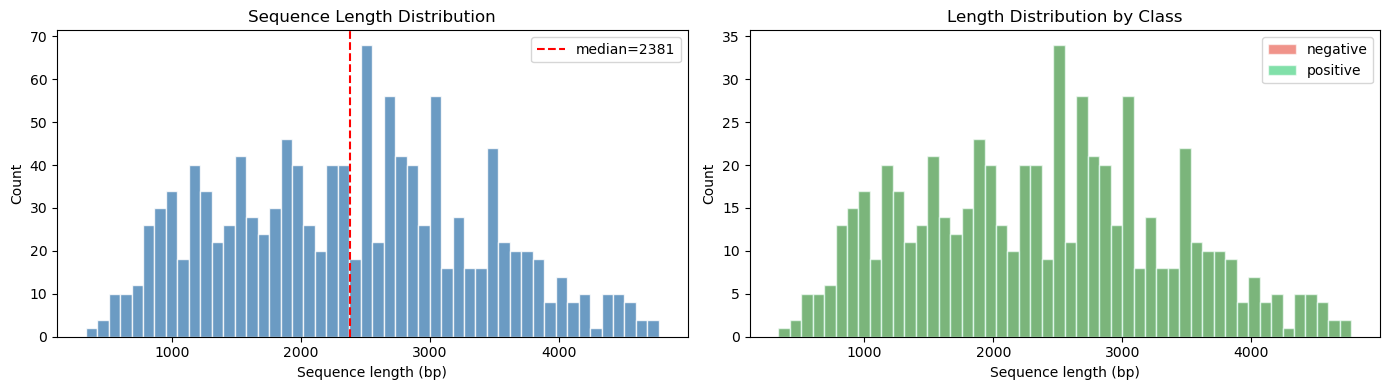

In [5]:
all_seqs = np.concatenate([train.X, valid.X, test.X])
all_labels = np.concatenate([train.y, valid.y, test.y]).flatten().astype(int)

lengths = np.array([len(s) for s in all_seqs])

print(f"Sequence length statistics (all {len(lengths)} sequences):")
print(f"  Min:    {lengths.min()}")
print(f"  Max:    {lengths.max()}")
print(f"  Mean:   {lengths.mean():.1f}")
print(f"  Median: {np.median(lengths):.1f}")
print(f"  Std:    {lengths.std():.1f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Overall histogram
axes[0].hist(lengths, bins=50, color="steelblue", edgecolor="white", alpha=0.8)
axes[0].axvline(np.median(lengths), color="red", linestyle="--", label=f"median={np.median(lengths):.0f}")
axes[0].set_xlabel("Sequence length (bp)")
axes[0].set_ylabel("Count")
axes[0].set_title("Sequence Length Distribution")
axes[0].legend()

# Per-class comparison
for label, color, name in [(0, "#e74c3c", "negative"), (1, "#2ecc71", "positive")]:
    mask = all_labels == label
    axes[1].hist(lengths[mask], bins=50, alpha=0.6, color=color, label=name, edgecolor="white")
axes[1].set_xlabel("Sequence length (bp)")
axes[1].set_ylabel("Count")
axes[1].set_title("Length Distribution by Class")
axes[1].legend()

plt.tight_layout()
plt.show()

## 4. Nucleotide composition

Mean nucleotide fractions across all sequences:
  A: 0.1940 ± 0.0769
  C: 0.1614 ± 0.0732
  G: 0.1601 ± 0.0722
  T: 0.1937 ± 0.0769
  N: 0.2908 ± 0.2772


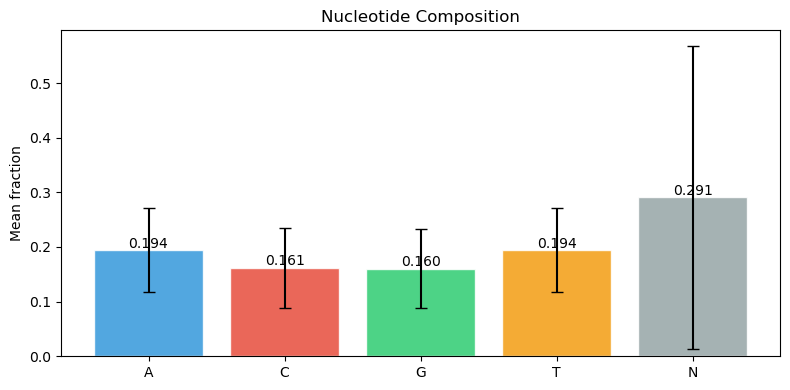

In [6]:
def nucleotide_freqs(sequences):
    """Compute per-sequence nucleotide frequencies."""
    results = []
    for seq in sequences:
        seq_upper = seq.upper()
        total = len(seq_upper)
        if total == 0:
            results.append({b: 0.0 for b in "ACGTN"})
            continue
        counts = Counter(seq_upper)
        results.append({b: counts.get(b, 0) / total for b in "ACGTN"})
    return results

freqs = nucleotide_freqs(all_seqs)
freq_arr = np.array([[f[b] for b in "ACGTN"] for f in freqs])

print("Mean nucleotide fractions across all sequences:")
for i, base in enumerate("ACGTN"):
    print(f"  {base}: {freq_arr[:, i].mean():.4f} ± {freq_arr[:, i].std():.4f}")

fig, ax = plt.subplots(figsize=(8, 4))
bases = list("ACGTN")
colors = ["#3498db", "#e74c3c", "#2ecc71", "#f39c12", "#95a5a6"]
means = [freq_arr[:, i].mean() for i in range(5)]
stds = [freq_arr[:, i].std() for i in range(5)]
bars = ax.bar(bases, means, yerr=stds, color=colors, edgecolor="white",
              capsize=4, alpha=0.85)
ax.set_ylabel("Mean fraction")
ax.set_title("Nucleotide Composition")
for bar, m in zip(bars, means):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
            f"{m:.3f}", ha="center", fontsize=10)
plt.tight_layout()
plt.show()

## 5. GC content

GC content (excluding N bases):
  Mean:   0.4230
  Median: 0.4449
  Std:    0.1177
  Min:    0.0000
  Max:    0.6250


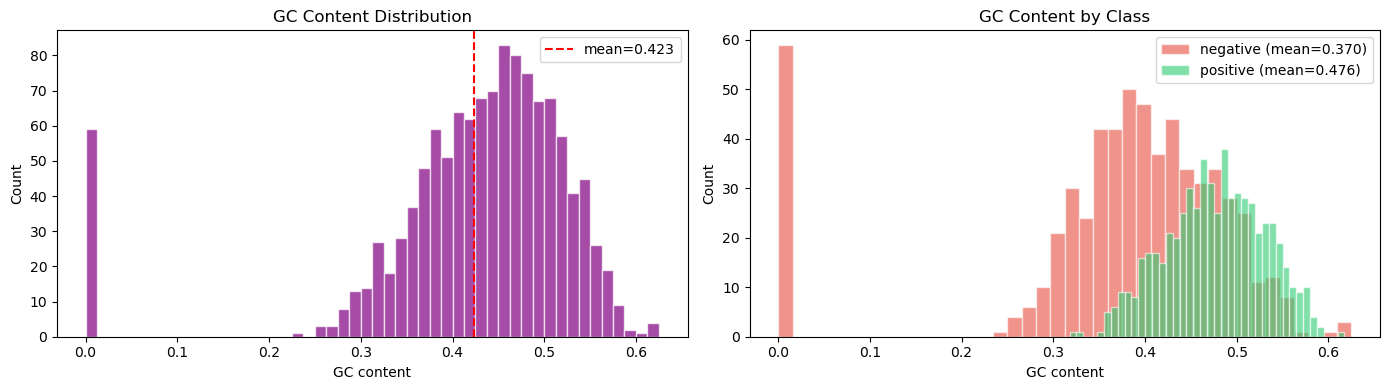

In [7]:
def gc_content(seq):
    """Fraction of G+C among non-N bases."""
    seq = seq.upper()
    gc = seq.count("G") + seq.count("C")
    non_n = len(seq) - seq.count("N")
    return gc / non_n if non_n > 0 else 0.0

gc_values = np.array([gc_content(s) for s in all_seqs])

print(f"GC content (excluding N bases):")
print(f"  Mean:   {gc_values.mean():.4f}")
print(f"  Median: {np.median(gc_values):.4f}")
print(f"  Std:    {gc_values.std():.4f}")
print(f"  Min:    {gc_values.min():.4f}")
print(f"  Max:    {gc_values.max():.4f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(gc_values, bins=50, color="purple", edgecolor="white", alpha=0.7)
axes[0].axvline(gc_values.mean(), color="red", linestyle="--",
                label=f"mean={gc_values.mean():.3f}")
axes[0].set_xlabel("GC content")
axes[0].set_ylabel("Count")
axes[0].set_title("GC Content Distribution")
axes[0].legend()

# Per-class
for label, color, name in [(0, "#e74c3c", "negative"), (1, "#2ecc71", "positive")]:
    mask = all_labels == label
    axes[1].hist(gc_values[mask], bins=40, alpha=0.6, color=color,
                 label=f"{name} (mean={gc_values[mask].mean():.3f})", edgecolor="white")
axes[1].set_xlabel("GC content")
axes[1].set_ylabel("Count")
axes[1].set_title("GC Content by Class")
axes[1].legend()

plt.tight_layout()
plt.show()

## 6. N-base contamination

Sequences with at least one N: 1144/1210 (94.5%)
Mean N fraction:   0.2908
Max N fraction:    1.0000
Median N fraction: 0.2072


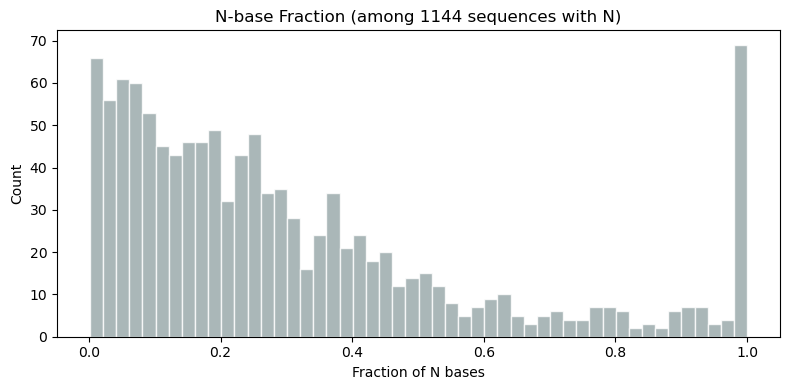

In [8]:
n_fracs = freq_arr[:, 4]  # column 4 = N

has_n = (n_fracs > 0).sum()
print(f"Sequences with at least one N: {has_n}/{len(n_fracs)} ({has_n/len(n_fracs):.1%})")
print(f"Mean N fraction:   {n_fracs.mean():.4f}")
print(f"Max N fraction:    {n_fracs.max():.4f}")
print(f"Median N fraction: {np.median(n_fracs):.4f}")

# Distribution of N fraction (only for sequences that have N)
n_fracs_nonzero = n_fracs[n_fracs > 0]
if len(n_fracs_nonzero) > 0:
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.hist(n_fracs_nonzero, bins=50, color="#95a5a6", edgecolor="white", alpha=0.8)
    ax.set_xlabel("Fraction of N bases")
    ax.set_ylabel("Count")
    ax.set_title(f"N-base Fraction (among {len(n_fracs_nonzero)} sequences with N)")
    plt.tight_layout()
    plt.show()
else:
    print("No sequences contain N bases.")

## 7. K-mer analysis (3-mers)

INFO:deepchem_genomics.feat.base_classes:Featurizing datapoint 0
INFO:deepchem_genomics.feat.base_classes:Featurizing datapoint 0
INFO:deepchem_genomics.feat.base_classes:Featurizing datapoint 0
INFO:deepchem_genomics.feat.base_classes:Featurizing datapoint 0
INFO:deepchem_genomics.feat.base_classes:Featurizing datapoint 0
INFO:deepchem_genomics.feat.base_classes:Featurizing datapoint 0
INFO:deepchem_genomics.feat.base_classes:Featurizing datapoint 0
INFO:deepchem_genomics.feat.base_classes:Featurizing datapoint 0
INFO:deepchem_genomics.feat.base_classes:Featurizing datapoint 0
INFO:deepchem_genomics.feat.base_classes:Featurizing datapoint 0
INFO:deepchem_genomics.feat.base_classes:Featurizing datapoint 0
INFO:deepchem_genomics.feat.base_classes:Featurizing datapoint 0
INFO:deepchem_genomics.feat.base_classes:Featurizing datapoint 0
INFO:deepchem_genomics.feat.base_classes:Featurizing datapoint 0
INFO:deepchem_genomics.feat.base_classes:Featurizing datapoint 0
INFO:deepchem_genomics.fe

Total unique 3-mers observed: 64 / 64 possible

Top 20 most frequent 3-mers:
  TTT: 43,569
  AAA: 43,032
  CTG: 39,472
  CAG: 39,454
  TCT: 37,089
  AGA: 36,762
  CTT: 33,822
  AAG: 33,668
  ACA: 33,405
  CCT: 33,350
  TGT: 33,135
  AGG: 32,871
  CCA: 31,892
  GAA: 31,565
  TTC: 31,515
  TGG: 31,280
  CTC: 30,637
  TCA: 30,386
  TGA: 30,228
  GAG: 30,122


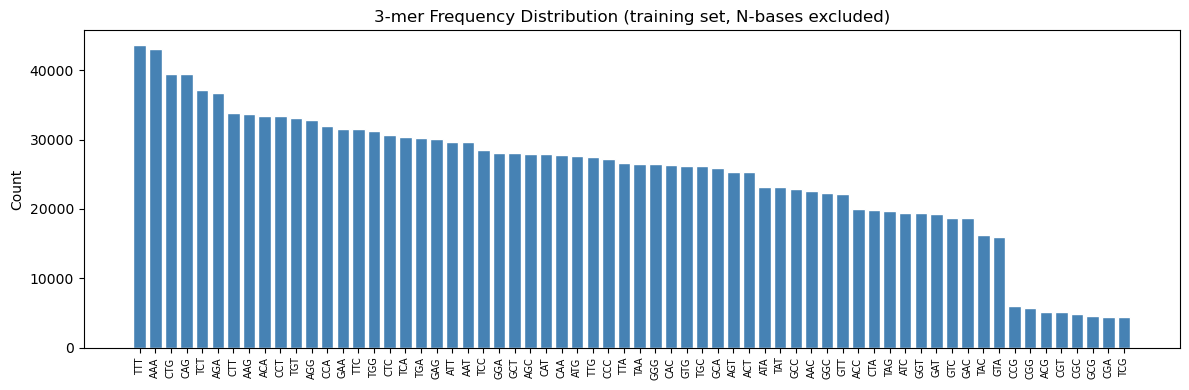

In [9]:
featurizer = DNAKmerFeaturizer(k=3)

# Collect 3-mer frequencies across all training sequences (stripping N first)
kmer_counter = Counter()
for seq in train.X:
    clean = seq.upper().replace("N", "")
    if len(clean) >= 3:
        kmers = featurizer.featurize([clean])[0]
        kmer_counter.update(kmers)

top_20 = kmer_counter.most_common(20)
bottom_10 = kmer_counter.most_common()[-10:]

print(f"Total unique 3-mers observed: {len(kmer_counter)} / 64 possible")
print(f"\nTop 20 most frequent 3-mers:")
for kmer, count in top_20:
    print(f"  {kmer}: {count:,}")

fig, ax = plt.subplots(figsize=(12, 4))
kmers_sorted = kmer_counter.most_common()
ax.bar(range(len(kmers_sorted)),
       [c for _, c in kmers_sorted],
       color="steelblue", edgecolor="white")
ax.set_xticks(range(len(kmers_sorted)))
ax.set_xticklabels([k for k, _ in kmers_sorted], rotation=90, fontsize=7)
ax.set_ylabel("Count")
ax.set_title("3-mer Frequency Distribution (training set, N-bases excluded)")
plt.tight_layout()
plt.show()

## 8. Featurization shape check

INFO:deepchem_genomics.feat.base_classes:Featurizing datapoint 0


One-hot featurizer with max_length=512
  Input:  5 sequences
  Output shape: (5, 512, 4)
  Dtype: float32
  Memory per sequence: 8.0 KB
  Memory for full train set (est): 7.6 MB

Sequences longer than 512bp: 1204/1210 (99.5%)
  → These will be truncated by the featurizer.


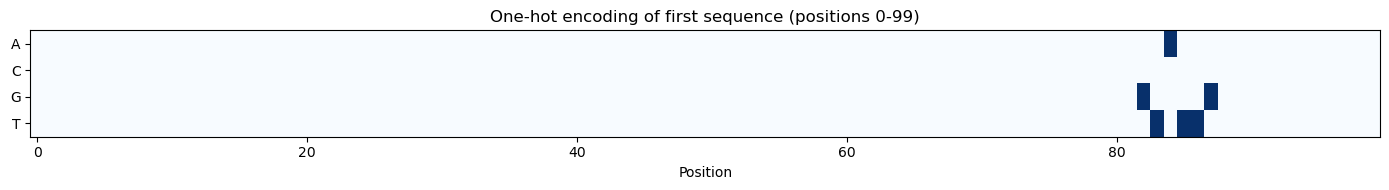

In [10]:
MAX_LEN = 512
onehot = DNAOneHotFeaturizer(max_length=MAX_LEN)

# Featurize a small batch
sample = train.X[:5]
encoded = onehot.featurize(sample)

print(f"One-hot featurizer with max_length={MAX_LEN}")
print(f"  Input:  {len(sample)} sequences")
print(f"  Output shape: {encoded.shape}")
print(f"  Dtype: {encoded.dtype}")
print(f"  Memory per sequence: {encoded[0].nbytes / 1024:.1f} KB")
print(f"  Memory for full train set (est): {len(train) * encoded[0].nbytes / 1024 / 1024:.1f} MB")

# How many sequences exceed MAX_LEN?
exceeds = sum(1 for s in all_seqs if len(s) > MAX_LEN)
print(f"\nSequences longer than {MAX_LEN}bp: {exceeds}/{len(all_seqs)} ({exceeds/len(all_seqs):.1%})")
print(f"  → These will be truncated by the featurizer.")

# Visualize one-hot encoding of first sequence
fig, ax = plt.subplots(figsize=(14, 2))
# Show first 100 positions
show_len = min(100, MAX_LEN)
ax.imshow(encoded[0][:show_len].T, aspect="auto", cmap="Blues",
          interpolation="nearest")
ax.set_yticks([0, 1, 2, 3])
ax.set_yticklabels(["A", "C", "G", "T"])
ax.set_xlabel("Position")
ax.set_title(f"One-hot encoding of first sequence (positions 0-{show_len-1})")
plt.tight_layout()
plt.show()

## 9. Summary table

In [11]:
print(f"{'='*60}")
print(f"Dataset Summary: {DATASET_NAME}")
print(f"{'='*60}")
print(f"{'Split':<8} {'Total':>7} {'Neg':>7} {'Pos':>7} {'Pos%':>7}")
print(f"{'-'*60}")
for name, ds in [("Train", train), ("Valid", valid), ("Test", test)]:
    labels = ds.y.flatten().astype(int)
    n_pos = (labels == 1).sum()
    n_neg = (labels == 0).sum()
    print(f"{name:<8} {len(ds):>7} {n_neg:>7} {n_pos:>7} {n_pos/len(ds):>7.1%}")
print(f"{'-'*60}")
total = len(train) + len(valid) + len(test)
print(f"{'Total':<8} {total:>7}")
print()
print(f"Sequence length: {lengths.min()}-{lengths.max()} bp (mean {lengths.mean():.0f})")
print(f"GC content:      {gc_values.mean():.3f} ± {gc_values.std():.3f}")
print(f"N-base seqs:     {has_n}/{len(all_seqs)} ({has_n/len(all_seqs):.0%})")
print(f"Unique 3-mers:   {len(kmer_counter)}/64")
print(f"{'='*60}")

Dataset Summary: dummy_mouse_enhancers_ensembl
Split      Total     Neg     Pos    Pos%
------------------------------------------------------------
Train        968     484     484   50.0%
Valid        121      62      59   48.8%
Test         121      59      62   51.2%
------------------------------------------------------------
Total       1210

Sequence length: 331-4776 bp (mean 2370)
GC content:      0.423 ± 0.118
N-base seqs:     1144/1210 (95%)
Unique 3-mers:   64/64
